In [1]:
import pandas as pd
import numpy as np

In [2]:
#한투 HTS 자료
ret_df = pd.read_csv('data/daily_ret.csv')
ret_df.head()

,기간,총입금액수익률,잔액기준수익률,평잔수익률,KOSPI수익률,KOSPI초과수익률,KOSDAQ수익률,KOSDAQ초과수익률,투자이익,기초자산,...,입금고,출금고,배당금,예탁금이자,수수료,세금,상환이자,보존입금액,보존출금액,투자원금
0,2022-04-03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,"221,852,554",...,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,"221,852,554"
1,2022-04-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,"221,852,554",...,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,"221,852,554"
2,2022-04-01,-0.88,-0.88,-0.89,-0.65,-0.23,-0.42,-0.46,"-1,989,850","223,842,404",...,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,"223,842,404"
3,2022-03-31,0.54,0.54,0.54,0.40,0.14,0.58,-0.03,"1,217,300","222,625,104",...,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,"222,625,104"
4,2022-03-30,0.00,0.00,0.00,0.21,-0.20,0.13,-0.12,"15,330","222,609,774",...,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,"222,609,774"


In [3]:
ret_df.columns

Index(['기간', '총입금액수익률', '잔액기준수익률', '평잔수익률', 'KOSPI수익률', 'KOSPI초과수익률',
       'KOSDAQ수익률', 'KOSDAQ초과수익률', '투자이익', '기초자산', '기말자산', '기말대출잔액', '입금고',
       '출금고', '배당금', '예탁금이자', '수수료', '세금', '상환이자', '보존입금액', '보존출금액', '투자원금'],
      dtype='object')

In [4]:
#쓸데없는 데이터 제거
df2 = ret_df[['기간', '총입금액수익률', 'KOSPI수익률', '투자원금']]
df2.head()

,기간,총입금액수익률,KOSPI수익률,투자원금
0,2022-04-03,0.00,0.00,"221,852,554"
1,2022-04-02,0.00,0.00,"221,852,554"
2,2022-04-01,-0.88,-0.65,"223,842,404"
3,2022-03-31,0.54,0.40,"222,625,104"
4,2022-03-30,0.00,0.21,"222,609,774"


In [5]:
df2.tail(5)

,기간,총입금액수익률,KOSPI수익률,투자원금
151,2021-11-03,0.0,-1.25,"232,117,193"
152,2021-11-02,0.0,1.16,"232,117,193"
153,2021-11-01,0.0,0.00,"232,117,193"
154,NaN,NaN,NaN,NaN
155,NaN,NaN,NaN,NaN


In [6]:
#날짜인덱스 만들기, 투자개시시점부터 데이터 자르기, dropna
df2['기간'] = pd.to_datetime(df2['기간'])
df2 = df2.set_index(df2['기간'])
df2.drop(['기간'], axis=1, inplace = True)
df2 = df2.sort_index(ascending=True)
df2 = df2['2021-12-06':]
df2 = df2.dropna()
df2.head()

<ipython-input-6-55355d613820>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['기간'] = pd.to_datetime(df2['기간'])


,총입금액수익률,KOSPI수익률,투자원금
기간,,,
2021-12-06,0.01,0.17,"232,117,193"
2021-12-07,-0.50,0.62,"232,147,181"
2021-12-08,0.69,0.34,"230,975,081"
2021-12-09,0.15,0.93,"232,586,141"
2021-12-10,-0.27,-0.64,"232,954,351"


In [7]:
#누적수익률 계산
df2['계좌 누적'] = ((df2['총입금액수익률']/100+1).cumprod()-1)*100
df2['KOSPI 누적'] = ((df2['KOSPI수익률']/100+1).cumprod()-1)*100
df2.head()

,총입금액수익률,KOSPI수익률,투자원금,계좌 누적,KOSPI 누적
기간,,,,,
2021-12-06,0.01,0.17,"232,117,193",0.010000,0.170000
2021-12-07,-0.50,0.62,"232,147,181",-0.490050,0.791054
2021-12-08,0.69,0.34,"230,975,081",0.196569,1.133744
2021-12-09,0.15,0.93,"232,586,141",0.346864,2.074287
2021-12-10,-0.27,-0.64,"232,954,351",0.075927,1.421012


In [8]:
#최종 누적수익률
df2.tail()

,총입금액수익률,KOSPI수익률,투자원금,계좌 누적,KOSPI 누적
기간,,,,,
2022-03-30,0.00,0.21,"222,609,774",-4.065690,-7.409726
2022-03-31,0.54,0.40,"222,625,104",-3.547645,-7.039365
2022-04-01,-0.88,-0.65,"223,842,404",-4.396426,-7.643609
2022-04-02,0.00,0.00,"221,852,554",-4.396426,-7.643609
2022-04-03,0.00,0.00,"221,852,554",-4.396426,-7.643609


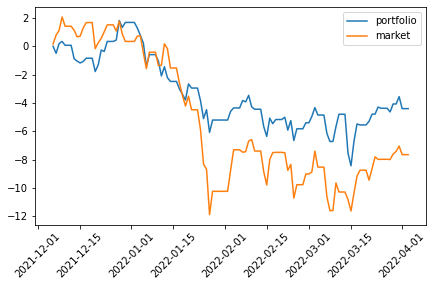

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(df2['계좌 누적'], label = 'portfolio')
plt.plot(df2['KOSPI 누적'], label = 'market')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [10]:
#예탁결제원 KOFR 자료
df_rfrate = pd.read_excel('data/KOFR.xls', skiprows=4)
df_rfrate['일자'] = pd.to_datetime(df_rfrate['일자'])
df_rfrate = df_rfrate.set_index('일자')
df_rate = df_rfrate['KOFR'].to_frame()
df_rate.sort_index(ascending = True, inplace=True)
df_rate.head()

,KOFR
일자,
2021-12-06,0.828
2021-12-07,1.018
2021-12-08,1.019
2021-12-09,1.124
2021-12-10,1.107


In [11]:
#주말, 공휴일 제외하고, KOFR과 합치기
df3 = df2.drop(df2[(df2['KOSPI수익률'] == 0) & (df2['총입금액수익률'] == 0)].index)
df3 = df3.join(df_rate, how='left')
df3['KOFR'] = df3['KOFR'] ** (1/12)

In [ ]:
#기간 중 포트폴리오 평균수익률, 변동성, 샤프지수, MDD 계산(월간데이터가 부족하여 일간데이터 * 20)
mean_ret = df3['총입금액수익률'].mean() * 20
port_std = df3['총입금액수익률'].std() * np.sqrt(20)
sharpie = (mean_ret - df3['KOFR'].mean())/port_std
mdd = (df3['계좌 누적'].max() - df3['계좌 누적'].min()) / (df3['계좌 누적'].max() + 100)

In [12]:
#기간 중 KOSPI 평균수익률, 변동성, 샤프지수, MDD 계산(월간데이터가 부족하여 일간데이터 * 20)
mean_ret_mkt = df3['KOSPI수익률'].mean() * 20
port_std_mkt = df3['KOSPI수익률'].std() * np.sqrt(20)
sharpie_mkt = (mean_ret_mkt - df3['KOFR'].mean())/port_std_mkt
mdd_mkt = (df3['KOSPI 누적'].max() - df3['KOSPI 누적'].min()) / (df3['KOSPI 누적'].max() + 100)

In [13]:
mean_ret, port_std, sharpie, mdd

(-1.068354430379747,
 3.7479696115394328,
 -0.5555225964126368,
 0.10072590903379737)

In [14]:
mean_ret_mkt, port_std_mkt, sharpie_mkt, mdd_mkt

(-1.8911392405063288,
 4.938772802351709,
 -0.5881757951330361,
 0.13671011775563968)